# Trabalho Aplicado 1 - Análise de Séries Temporais

**Disciplina:** Análise de Séries Temporais - MAD485  
**Professor:** João Batista M. Pereira  
**Período:** 2026.1  
**Aluno:** Lenardo Yves  
**DRE:** 120041695  

**Tema:** modelagem e previsão da série mensal `pmc_volume_index` por modelos ARIMA/SARIMA.

Este notebook documenta o fluxo completo do trabalho: análise exploratória, estacionarização, estimação de modelos concorrentes, avaliação preditiva em período observado, diagnóstico do modelo selecionado e previsão futura com intervalo de incerteza.

## 1. Objetivo e desenho metodológico

A análise usa a série mensal `pmc_volume_index`, associada ao índice de volume de vendas da Pesquisa Mensal de Comércio. A coluna da SELIC, quando presente no arquivo bruto, é mantida apenas como informação contextual. O modelo principal é univariado.

A seleção do modelo não é feita apenas por AIC/BIC. Para que a previsão seja avaliável, os últimos 24 meses observados são reservados como teste. Os modelos são estimados no treino e comparados por erro preditivo no teste, além de critérios de informação e diagnóstico residual.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name.lower() == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_RAW = BASE_DIR / "data" / "raw" / "dataset_pmc_selic_monthly.csv"
DATA_PROCESSED = BASE_DIR / "data" / "processed" / "pmc_monthly_model_input.csv"
FIG_DIR = BASE_DIR / "reports" / "figures"
TABLE_DIR = BASE_DIR / "reports" / "tables"
LOG_DIR = BASE_DIR / "reports" / "logs"

for path in [FIG_DIR, TABLE_DIR, LOG_DIR, DATA_PROCESSED.parent]:
    path.mkdir(parents=True, exist_ok=True)

BASE_DIR


WindowsPath('G:/Meu Drive/UFRJ/2026/26.1/Análise de Séries Temporais/Avaliações/Trabalho Aplicado')

## 2. Carregamento e validação dos dados

Esta etapa verifica colunas obrigatórias, conversão da data, ordenação temporal, duplicatas, regularidade mensal e valores ausentes. A base de modelagem contém apenas `date` e `pmc_volume_index`.

In [2]:
df_raw = pd.read_csv(DATA_RAW)
df_raw.head()


,date,pmc_volume_index,selic_monthly_annualized
0,2000-01-01,46.56262,18.94
1,2000-02-01,47.08777,18.87
2,2000-03-01,49.10081,18.85
3,2000-04-01,49.10081,18.62
4,2000-05-01,51.11386,18.51


In [3]:
required = {"date", "pmc_volume_index"}
missing_cols = sorted(required.difference(df_raw.columns))
if missing_cols:
    raise ValueError(f"Colunas obrigatorias ausentes: {missing_cols}")

df = df_raw.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df["pmc_volume_index"] = pd.to_numeric(df["pmc_volume_index"], errors="coerce")
monthly_index = pd.date_range(df["date"].min(), df["date"].max(), freq="MS")
missing_dates = monthly_index.difference(pd.DatetimeIndex(df["date"]))

validation = {
    "n_observations": int(len(df)),
    "start": df["date"].min().strftime("%Y-%m-%d"),
    "end": df["date"].max().strftime("%Y-%m-%d"),
    "duplicated_dates": int(df["date"].duplicated().sum()),
    "missing_months": [d.strftime("%Y-%m-%d") for d in missing_dates],
    "missing_values": df.isna().sum().to_dict(),
    "raw_columns": list(df.columns),
}

with open(LOG_DIR / "validacao_dados_pmc_notebook.json", "w", encoding="utf-8") as f:
    json.dump(validation, f, indent=2, ensure_ascii=False)

pmc_df = df[["date", "pmc_volume_index"]].copy()
pmc_df.to_csv(DATA_PROCESSED, index=False)
series = pmc_df.set_index("date")["pmc_volume_index"].asfreq("MS")
validation


{'n_observations': 315,
 'start': '2000-01-01',
 'end': '2026-03-01',
 'duplicated_dates': 0,
 'missing_months': [],
 'missing_values': {'date': 0,
  'pmc_volume_index': 0,
  'selic_monthly_annualized': 0},
 'raw_columns': ['date', 'pmc_volume_index', 'selic_monthly_annualized']}

## 3. Análise exploratória dos dados

A EDA avalia nível, tendência visual, sazonalidade, variabilidade e autocorrelação. Essas evidências orientam a necessidade de diferenciação regular e sazonal.

In [4]:
desc = series.describe(percentiles=[0.25, 0.5, 0.75]).to_frame("pmc_volume_index")
extra = pd.DataFrame({"pmc_volume_index": {
    "start": series.index.min().strftime("%Y-%m-%d"),
    "end": series.index.max().strftime("%Y-%m-%d"),
    "n_observations": len(series),
    "frequency": "monthly",
    "skewness": series.skew(),
    "kurtosis": series.kurtosis(),
}})
desc_table = pd.concat([desc, extra])
desc_table.to_csv(TABLE_DIR / "estatisticas_descritivas_pmc.csv")
desc_table


,pmc_volume_index
count,315.0
mean,81.784246
std,22.290201
min,43.32425
25%,60.04128
50%,88.92411
75%,97.520495
max,131.81074
start,2000-01-01
end,2026-03-01


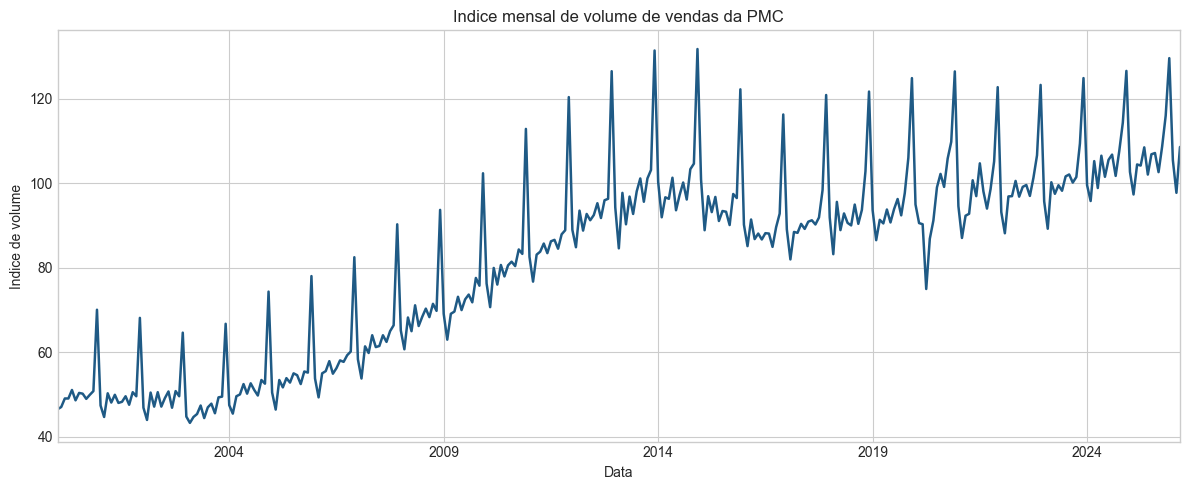

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
series.plot(ax=ax, color="#1f5a85", linewidth=1.8)
ax.set_title("Indice mensal de volume de vendas da PMC")
ax.set_xlabel("Data")
ax.set_ylabel("Indice de volume")
fig.tight_layout()
fig.savefig(FIG_DIR / "serie_pmc.png", dpi=180)
plt.show()


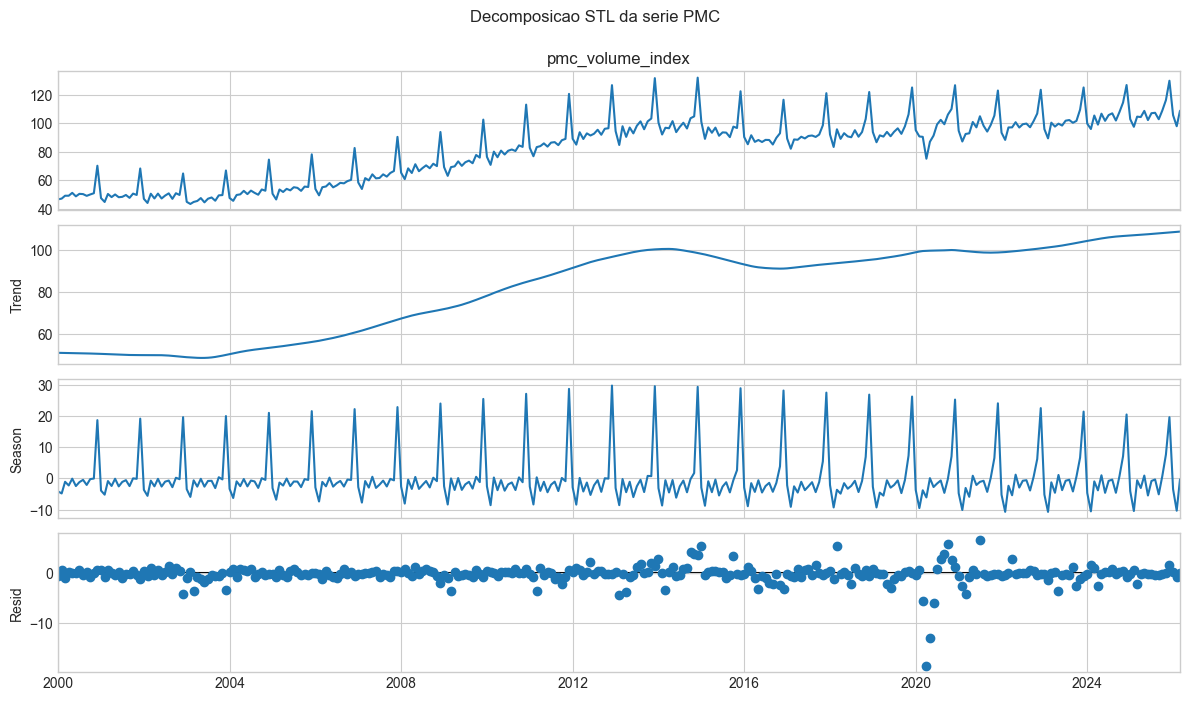

In [6]:
stl = STL(series, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 7)
fig.suptitle("Decomposicao STL da serie PMC", y=0.995)
fig.tight_layout()
fig.savefig(FIG_DIR / "decomposicao_stl_pmc.png", dpi=180)
plt.show()


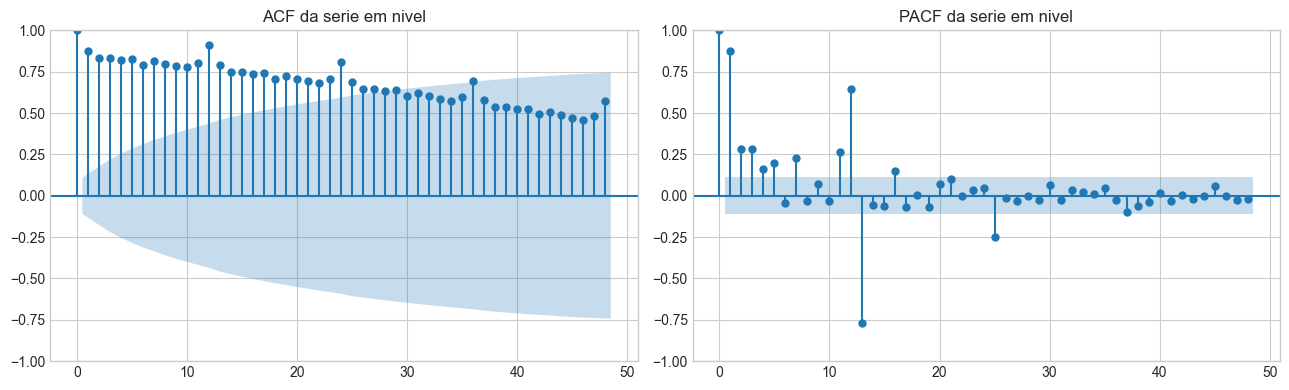

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series, lags=48, ax=axes[0])
plot_pacf(series, lags=48, ax=axes[1], method="ywm")
axes[0].set_title("ACF da serie em nivel")
axes[1].set_title("PACF da serie em nivel")
fig.tight_layout()
fig.savefig(FIG_DIR / "acf_pacf_pmc.png", dpi=180)
plt.show()


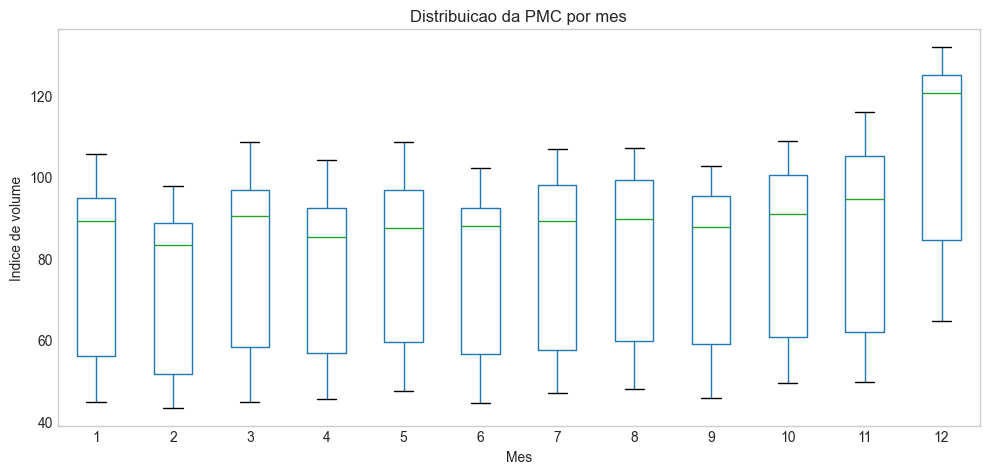

In [8]:
month_df = series.to_frame("pmc_volume_index")
month_df["month"] = month_df.index.month
fig, ax = plt.subplots(figsize=(10, 5))
month_df.boxplot(column="pmc_volume_index", by="month", ax=ax, grid=False)
fig.suptitle("")
ax.set_title("Distribuicao da PMC por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Indice de volume")
fig.tight_layout()
fig.savefig(FIG_DIR / "boxplot_mensal_pmc.png", dpi=180)
plt.show()


## 4. Estacionariedade e transformações

O ADF tem hipótese nula de raiz unitária. O KPSS tem hipótese nula de estacionariedade. A leitura conjunta ajuda a decidir se são necessárias diferenciação regular e sazonal.

In [9]:
def run_stationarity_tests(x, label):
    adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
    return {"transformacao": label, "adf_stat": adf_stat, "adf_pvalue": adf_p,
            "kpss_stat": kpss_stat, "kpss_pvalue": kpss_p, "n_obs": len(x)}

transforms = {
    "nivel": series,
    "diff_1": series.diff().dropna(),
    "diff_sazonal_12": series.diff(12).dropna(),
    "diff_1_e_sazonal_12": series.diff().diff(12).dropna(),
}
stationarity_table = pd.DataFrame([run_stationarity_tests(x, label) for label, x in transforms.items()])
stationarity_table.to_csv(TABLE_DIR / "testes_estacionariedade.csv", index=False)
stationarity_table


,transformacao,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue,n_obs
0,nivel,-1.019117,7.462280e-01,2.672367,0.01,315
1,diff_1,-3.228154,1.841178e-02,0.290506,0.10,314
2,diff_sazonal_12,-2.925330,4.248071e-02,0.268053,0.10,303
3,diff_1_e_sazonal_12,-5.744055,6.179991e-07,0.028464,0.10,302


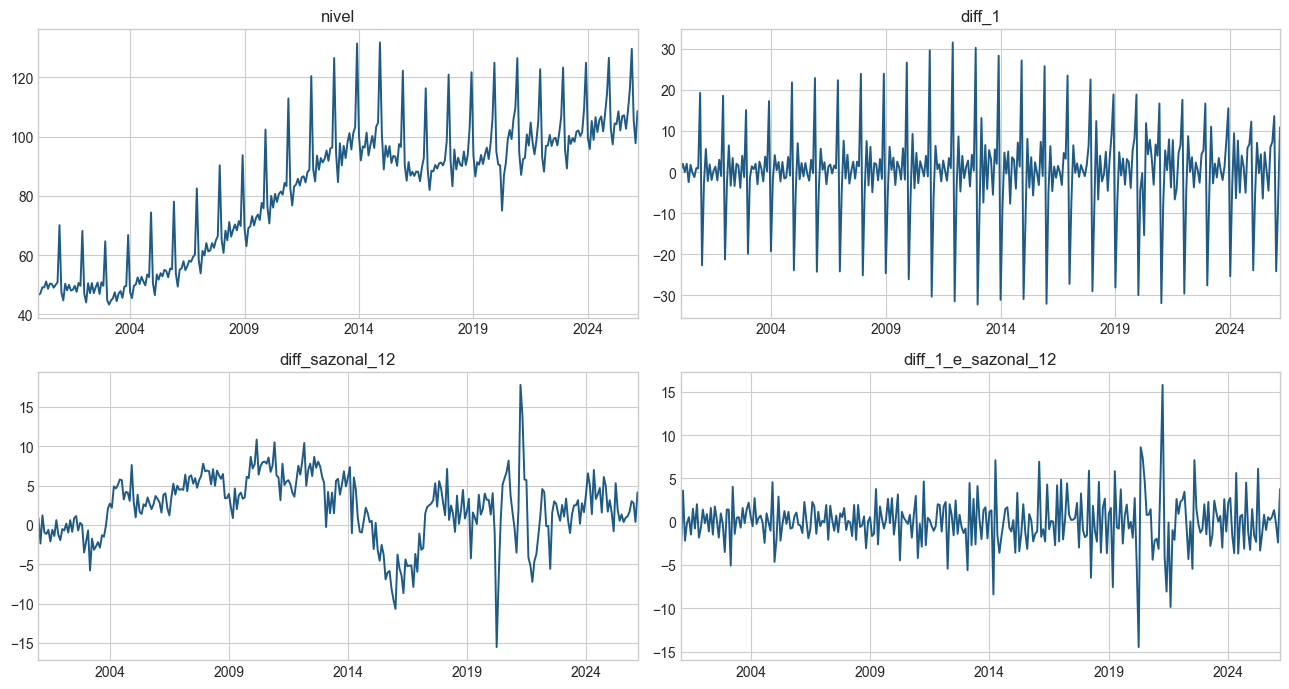

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (label, x) in zip(axes.ravel(), transforms.items()):
    x.plot(ax=ax, color="#1f5a85", linewidth=1.4)
    ax.set_title(label)
    ax.set_xlabel("")
fig.tight_layout()
plt.show()


## 5. Partição treino-teste

Os últimos 24 meses observados são reservados para teste. Assim, a previsão é avaliada contra valores reais do banco original.

In [11]:
TEST_SIZE = 24
train = series.iloc[:-TEST_SIZE]
test = series.iloc[-TEST_SIZE:]

split_table = pd.DataFrame([{
    "train_start": train.index.min().strftime("%Y-%m-%d"),
    "train_end": train.index.max().strftime("%Y-%m-%d"),
    "test_start": test.index.min().strftime("%Y-%m-%d"),
    "test_end": test.index.max().strftime("%Y-%m-%d"),
    "train_n": len(train),
    "test_n": len(test),
}])
split_table.to_csv(TABLE_DIR / "particao_treino_teste.csv", index=False)
split_table


,train_start,train_end,test_start,test_end,train_n,test_n
0,2000-01-01,2024-03-01,2024-04-01,2026-03-01,291,24


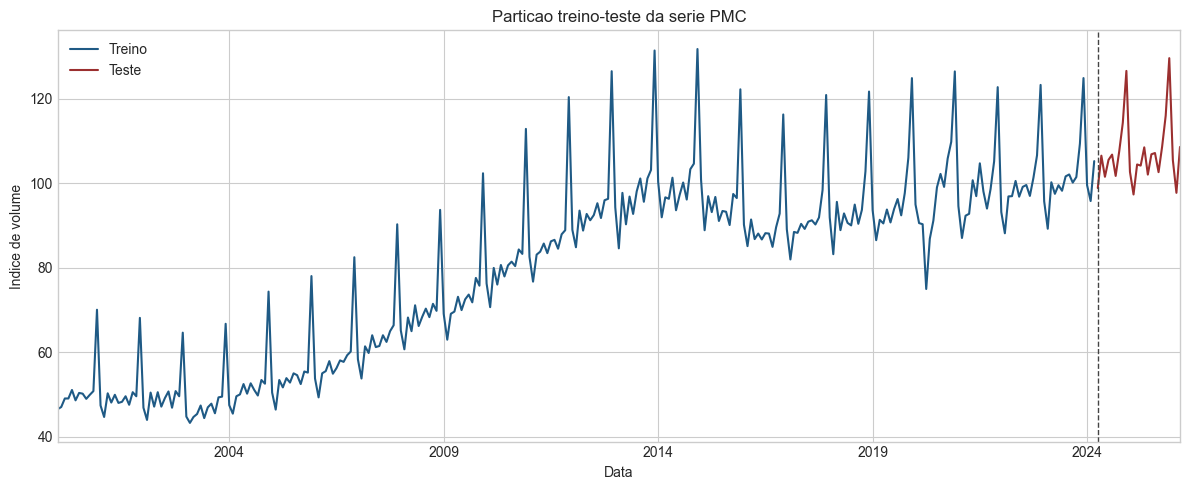

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
train.plot(ax=ax, label="Treino", color="#1f5a85")
test.plot(ax=ax, label="Teste", color="#9b2f2f")
ax.axvline(test.index.min(), color="#444444", linestyle="--", linewidth=1)
ax.set_title("Particao treino-teste da serie PMC")
ax.set_xlabel("Data")
ax.set_ylabel("Indice de volume")
ax.legend()
fig.tight_layout()
plt.show()


## 6. Estimação de modelos concorrentes

A grade inclui modelos ARIMA e SARIMA com sazonalidade mensal `m = 12`. Os modelos são comparados por AIC/BIC no treino e por MAE, RMSE e MAPE no teste.

In [13]:
candidates = [
    ("ARIMA(0,1,1)", (0,1,1), (0,0,0,0)),
    ("ARIMA(1,1,0)", (1,1,0), (0,0,0,0)),
    ("ARIMA(1,1,1)", (1,1,1), (0,0,0,0)),
    ("ARIMA(2,1,1)", (2,1,1), (0,0,0,0)),
    ("ARIMA(1,1,2)", (1,1,2), (0,0,0,0)),
    ("SARIMA(0,1,1)(0,1,1,12)", (0,1,1), (0,1,1,12)),
    ("SARIMA(1,1,1)(0,1,1,12)", (1,1,1), (0,1,1,12)),
    ("SARIMA(1,1,0)(1,1,0,12)", (1,1,0), (1,1,0,12)),
    ("SARIMA(0,1,1)(1,1,0,12)", (0,1,1), (1,1,0,12)),
    ("SARIMA(1,1,1)(1,1,1,12)", (1,1,1), (1,1,1,12)),
    ("SARIMA(0,1,2)(0,1,1,12)", (0,1,2), (0,1,1,12)),
    ("SARIMA(2,1,1)(0,1,1,12)", (2,1,1), (0,1,1,12)),
    ("SARIMA(2,1,2)(0,1,1,12)", (2,1,2), (0,1,1,12)),
    ("SARIMA(3,1,1)(0,1,1,12)", (3,1,1), (0,1,1,12)),
    ("SARIMA(1,1,3)(0,1,1,12)", (1,1,3), (0,1,1,12)),
    ("SARIMA(2,1,2)(0,1,2,12)", (2,1,2), (0,1,2,12)),
    ("SARIMA(3,1,3)(0,1,2,12)", (3,1,3), (0,1,2,12)),
]

def fit_sarimax(y, order, seasonal_order):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = SARIMAX(y, order=order, seasonal_order=seasonal_order, trend="n",
                        enforce_stationarity=False, enforce_invertibility=False)
        return model.fit(disp=False, maxiter=400)

rows = []
fitted_train = {}
for name, order, seasonal_order in candidates:
    try:
        fitted = fit_sarimax(train, order, seasonal_order)
        pred = fitted.get_forecast(steps=len(test)).predicted_mean
        pred.index = test.index
        error = test - pred
        resid = fitted.resid.dropna()
        lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
        rows.append({
            "modelo": name,
            "aic_treino": fitted.aic,
            "bic_treino": fitted.bic,
            "mae_teste": np.mean(np.abs(error)),
            "rmse_teste": np.sqrt(np.mean(np.square(error))),
            "mape_teste_pct": np.mean(np.abs(error / test)) * 100,
            "n_params": int(fitted.params.shape[0]),
            "converged": bool(fitted.mle_retvals.get("converged", False)),
            "ljung_box_pvalue_lag_12_treino": lb.loc[12, "lb_pvalue"],
            "ljung_box_pvalue_lag_24_treino": lb.loc[24, "lb_pvalue"],
        })
        fitted_train[name] = fitted
    except Exception as exc:
        rows.append({"modelo": name, "error": str(exc)})

model_table = pd.DataFrame(rows).sort_values(["rmse_teste", "mae_teste", "aic_treino"], na_position="last")
model_table.to_csv(TABLE_DIR / "selecao_modelos_arima_sarima.csv", index=False)
model_table.head(10)


,modelo,aic_treino,bic_treino,mae_teste,rmse_teste,mape_teste_pct,n_params,converged,ljung_box_pvalue_lag_12_treino,ljung_box_pvalue_lag_24_treino
14,"SARIMA(1,1,3)(0,1,1,12)",1238.254115,1259.664182,1.454632,1.777729,1.354699,6,True,1.137717e-10,3.461901e-07
13,"SARIMA(3,1,1)(0,1,1,12)",1245.613257,1267.068951,1.460492,1.786881,1.359955,6,True,1.170813e-10,3.997962e-07
11,"SARIMA(2,1,1)(0,1,1,12)",1243.618013,1261.497758,1.460922,1.787695,1.360373,5,True,1.167797e-10,3.987523e-07
9,"SARIMA(1,1,1)(1,1,1,12)",1243.624567,1261.504313,1.461683,1.789035,1.361103,5,True,1.146784e-10,3.904507e-07
6,"SARIMA(1,1,1)(0,1,1,12)",1241.625192,1255.928988,1.461685,1.789038,1.361107,4,True,1.148043e-10,3.907716e-07
15,"SARIMA(2,1,2)(0,1,2,12)",1188.534308,1213.212479,1.508208,1.848598,1.401932,7,True,1.268759e-07,7.135467e-06
16,"SARIMA(3,1,3)(0,1,2,12)",1186.111195,1217.804344,1.518346,1.865373,1.413153,9,True,5.468458e-10,6.395168e-12
12,"SARIMA(2,1,2)(0,1,1,12)",1239.541465,1260.974389,1.516295,1.871895,1.413474,6,True,3.011989e-06,8.007744e-05
10,"SARIMA(0,1,2)(0,1,1,12)",1241.940705,1256.229321,1.762006,2.149884,1.640402,4,True,2.400435e-06,1.036616e-03
5,"SARIMA(0,1,1)(0,1,1,12)",1250.842340,1261.570187,3.083576,3.508418,2.876991,3,True,1.973923e-06,8.263576e-04


## 7. Modelo selecionado e risco preditivo

O modelo selecionado é o que apresenta menor RMSE no teste. Esta é uma avaliação retrospectiva: a previsão cobre um período que existe no banco original.

In [14]:
selected_name = model_table.dropna(subset=["rmse_teste"]).iloc[0]["modelo"]
selected_train_fit = fitted_train[selected_name]
selected_name


'SARIMA(1,1,3)(0,1,1,12)'

In [15]:
test_forecast = selected_train_fit.get_forecast(steps=len(test))
test_pred = test_forecast.predicted_mean
test_pred.index = test.index
test_conf = test_forecast.conf_int(alpha=0.05)
test_conf.index = test.index

test_error = test - test_pred
test_forecast_table = pd.DataFrame({
    "date": test.index,
    "observed": test.values,
    "forecast": test_pred.values,
    "error": test_error.values,
    "absolute_error": np.abs(test_error.values),
    "absolute_percentage_error": np.abs(test_error.values / test.values) * 100,
    "lower_95": test_conf.iloc[:, 0].values,
    "upper_95": test_conf.iloc[:, 1].values,
})
test_forecast_table.to_csv(TABLE_DIR / "previsao_teste_24m.csv", index=False)

risk_table = pd.DataFrame([{
    "modelo_final": selected_name,
    "mae": test_forecast_table["absolute_error"].mean(),
    "rmse": np.sqrt(np.mean(np.square(test_forecast_table["error"]))),
    "mape_pct": test_forecast_table["absolute_percentage_error"].mean(),
    "max_abs_error": test_forecast_table["absolute_error"].max(),
    "test_start": test.index.min().strftime("%Y-%m-%d"),
    "test_end": test.index.max().strftime("%Y-%m-%d"),
    "test_n": len(test),
}])
risk_table.to_csv(TABLE_DIR / "risco_preditivo_teste_24m.csv", index=False)
risk_table


,modelo_final,mae,rmse,mape_pct,max_abs_error,test_start,test_end,test_n
0,"SARIMA(1,1,3)(0,1,1,12)",1.454632,1.777729,1.354699,3.449183,2024-04-01,2026-03-01,24


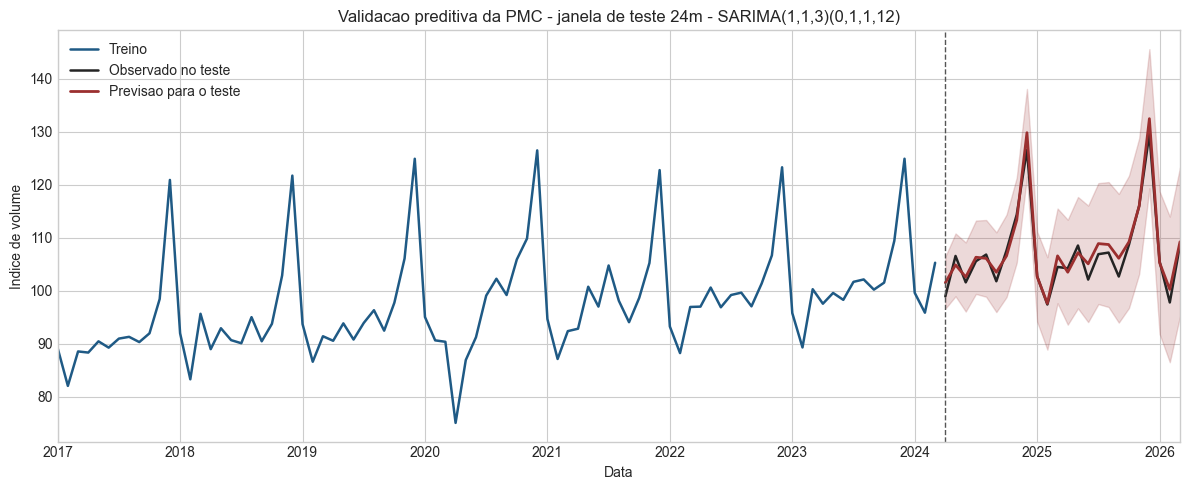

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
train.loc["2017":].plot(ax=ax, label="Treino", color="#1f5a85", linewidth=1.8)
test.plot(ax=ax, label="Observado no teste", color="#242424", linewidth=1.8)
test_pred.plot(ax=ax, label="Previsao para o teste", color="#9b2f2f", linewidth=2)
ax.fill_between(test.index, test_conf.iloc[:, 0], test_conf.iloc[:, 1], color="#9b2f2f", alpha=0.18)
ax.axvline(test.index.min(), color="#555555", linestyle="--", linewidth=1)
ax.set_title(f"Validacao preditiva da PMC - janela de teste 24m - {selected_name}")
ax.set_xlabel("Data")
ax.set_ylabel("Indice de volume")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "previsao_teste_pmc_24m.png", dpi=180)
plt.show()


## 8. Reestimação na amostra completa e diagnóstico

Após escolher o modelo no teste, a mesma especificação é reestimada na amostra completa. Esta versão é usada para diagnóstico final e previsão futura.

In [17]:
selected_spec = {name: (order, seasonal_order) for name, order, seasonal_order in candidates}[selected_name]
final_fit = fit_sarimax(series, *selected_spec)
print(final_fit.summary())


                                      SARIMAX Results                                       
Dep. Variable:                     pmc_volume_index   No. Observations:                  315
Model:             SARIMAX(1, 1, 3)x(0, 1, [1], 12)   Log Likelihood                -664.471
Date:                              Sat, 30 May 2026   AIC                           1340.943
Time:                                      22:28:03   BIC                           1362.879
Sample:                                  01-01-2000   HQIC                          1349.735
                                       - 03-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4809      0.305      1.579      0.114      -0.116       1.078
ma.L1         -0.83

In [18]:
resid = final_fit.resid.dropna()
ljung = acorr_ljungbox(resid, lags=[6, 12, 18, 24], return_df=True)
ljung.to_csv(TABLE_DIR / "diagnostico_residuos.csv", index_label="lag")
ljung


,lb_stat,lb_pvalue
6,23.355834,6.856534e-04
12,77.821009,1.072751e-11
18,79.967395,8.682582e-10
24,80.915968,4.344913e-08


In [19]:
residual_summary = pd.DataFrame({
    "metrica": ["modelo_final", "media_residuos", "desvio_padrao_residuos", "assimetria_residuos", "curtose_residuos", "shapiro_pvalue"],
    "valor": [selected_name, resid.mean(), resid.std(), stats.skew(resid), stats.kurtosis(resid), stats.shapiro(resid.sample(min(len(resid), 500), random_state=123)).pvalue],
})
residual_summary.to_csv(TABLE_DIR / "resumo_modelo_final.csv", index=False)
residual_summary


,metrica,valor
0,modelo_final,"SARIMA(1,1,3)(0,1,1,12)"
1,media_residuos,0.113867
2,desvio_padrao_residuos,5.023255
3,assimetria_residuos,-2.331124
4,curtose_residuos,79.348855
5,shapiro_pvalue,0.0


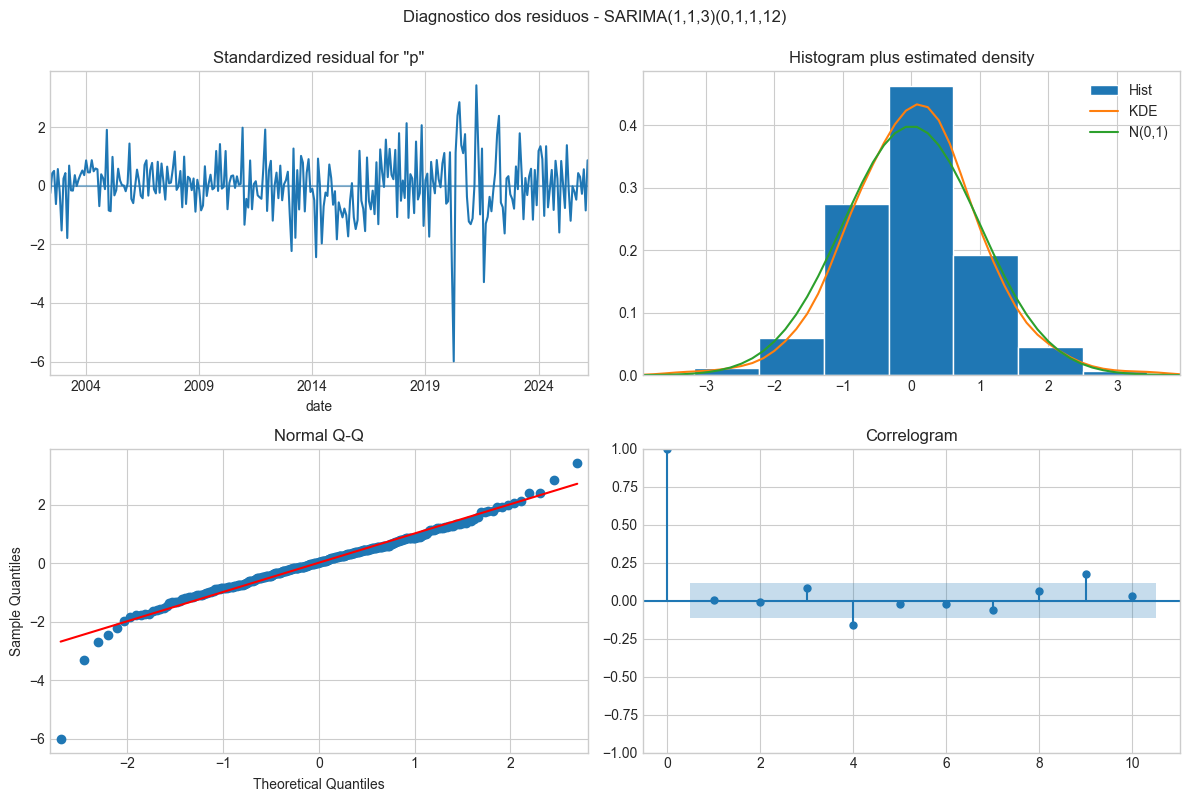

In [20]:
fig = final_fit.plot_diagnostics(figsize=(12, 8))
fig.suptitle(f"Diagnostico dos residuos - {selected_name}", y=0.995)
fig.tight_layout()
fig.savefig(FIG_DIR / "diagnostico_residuos_modelo_final.png", dpi=180)
plt.show()


## 9. Previsão futura

A previsão futura é feita somente depois da avaliação retrospectiva. Ela não participa da seleção do modelo; é o produto final do modelo selecionado e reestimado na amostra completa.

In [21]:
future_forecast = final_fit.get_forecast(steps=12)
future_pred = future_forecast.predicted_mean
future_conf = future_forecast.conf_int(alpha=0.05)

future_table = pd.DataFrame({
    "date": future_pred.index,
    "forecast": future_pred.values,
    "lower_95": future_conf.iloc[:, 0].values,
    "upper_95": future_conf.iloc[:, 1].values,
})
future_table.to_csv(TABLE_DIR / "previsoes_12m.csv", index=False)
future_table


,date,forecast,lower_95,upper_95
0,2026-04-01,105.586345,100.753209,110.419481
1,2026-05-01,110.509051,104.759378,116.258723
2,2026-06-01,105.583514,99.282798,111.884230
3,2026-07-01,109.878156,103.200879,116.555432
4,2026-08-01,110.266986,103.286632,117.247340
5,2026-09-01,106.148109,98.900545,113.395673
6,2026-10-01,111.307096,103.812309,118.801884
7,2026-11-01,118.335702,110.606402,126.065002
8,2026-12-01,132.424696,124.470023,140.379368
9,2027-01-01,107.487169,99.314378,115.659961


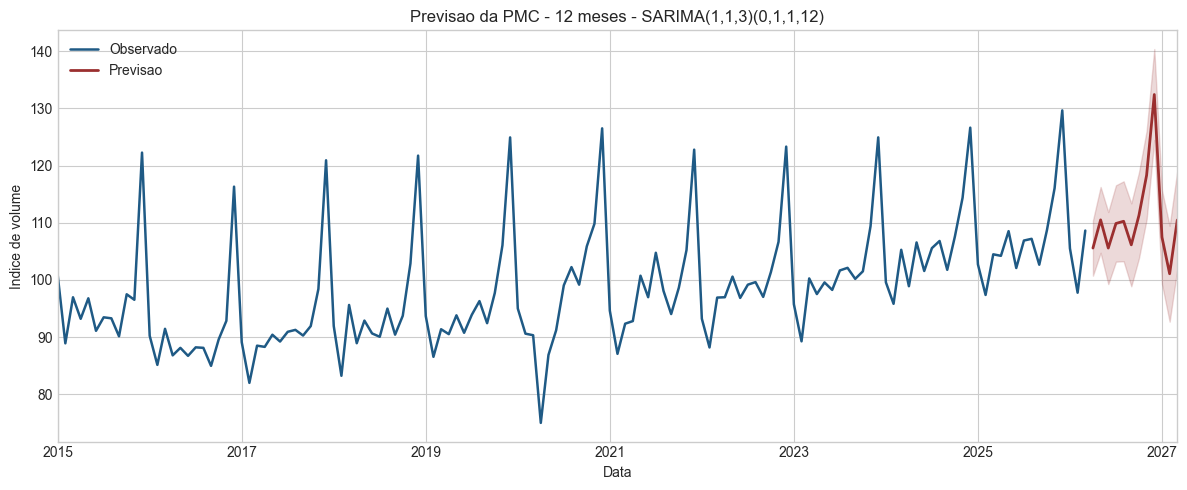

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
series.loc["2015":].plot(ax=ax, label="Observado", color="#1f5a85", linewidth=1.8)
future_pred.plot(ax=ax, label="Previsao", color="#9b2f2f", linewidth=2)
ax.fill_between(future_pred.index, future_conf.iloc[:, 0], future_conf.iloc[:, 1], color="#9b2f2f", alpha=0.18)
ax.set_title(f"Previsao da PMC - 12 meses - {selected_name}")
ax.set_xlabel("Data")
ax.set_ylabel("Indice de volume")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "previsao_pmc_12m.png", dpi=180)
plt.show()


## 10. Síntese crítica

O modelo selecionado por risco preditivo deve ser apresentado como um baseline SARIMA competitivo para previsão. Se o teste de Ljung-Box indicar autocorrelação residual, isso deve ser discutido explicitamente como limitação: a série pode conter choques, quebras estruturais ou componentes não capturados por um SARIMA simples.